### 神经网络
人工神经网络(Artificial Neural Network, ANN) 也称之为神经网络，是一种模仿生物神经网络结构和功能的**计算模型**。
特点：
1. 同一层的神经元之间没有连接
2. 第 N 层的每个神经元和第 N-1 层的所有神经元相连（这就是full connected的含义），这就是全连接神经网络
3. 全连接神经网络接受的样本数据是二维的，数据在每一层之间需要以二维的形式传递
4. 第 N-1 层神经元的输出就是第 N 层神经元的输入
5. 每个连接都有一个权重值（w系数和b系数）

每一个神经元工作时，前向传播会产生两个值，内部状态值（加权求和值）和激活值；反向传播时会产生激活值梯度和内部状态值梯度
内部状态值：神经元或隐藏单元的内部存储值，它反映了当前神经元接受到的输入、历史信息以及网络内部的权重计算结果。 z = Wx + b
激活值：通过激活函数（ReLu，Sigmoid，Tanh）对内部状态值进行非线性变换后得到的结果。 a = f(z)

### 激活函数
激活函数用于对每层的输出数据进行变换，进而为整个网络注入了非线性因素。此时，神经网络就可以拟合各种曲线。
1. 没有引入非线性因素的网络等价于使用一个线性模型来拟合
2. 通过给网络输出增加激活函数，实现引入非线性因素，使得网络模型可以逼近任意函数，提升网络对复杂问题的拟合能力。

#### sigmoid激活函数
激活函数公式：$ f(x)=\frac{1}{1+e^{-x}} $
激活函数求导公式：$ f'(x)=(\frac{1}{1+e^{-x}})'=\frac{1}{1+e^{-x}}(1-\frac{1}{1+e^{-x}})=f(x)(1-f(x)) $

sigmoid函数可以将任意的输入映射到 (0,1) 之间，当输入的值大致在<-6 或者 >6时，意味着输入任何值所得到的激活值都是差不多的，这样会丢失部分的信息。比如：输入100 和 输入 10000 经过sigmoid的激活值几乎都是等于1的，但是输入的数据之间相差100倍的信息就丢失了。
对于sigmoid函数而言，输入值在 [-6, 6] 之间输出值才有明显差异，输入值在 [-3, 3] 之间才会有比较好的效果
通过导数图像，可以发现导数数值范围在 (0, 0.25)，当输入 < -6 或者 > 6 时，sigmoid激活函数图像的导数接近为0，此时网络参数将更新及其缓慢，或者无法更新
一般开始，sigmoid 网络在 5 层之内就会产生梯度消失现象。而且，该激活函数并不是以 0 为中心的，所以在实践中这种激活函数使用的很少。**sigmoid函数一般只用于二分类的输出层**。

Text(0.5, 1.0, 'Sigmoid 激活函数的导数图像')

D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 20989 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 25968 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 22270 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 20687 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Program Files\Anaconda\anaconda3\envs\pytorch\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 28608 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Pr

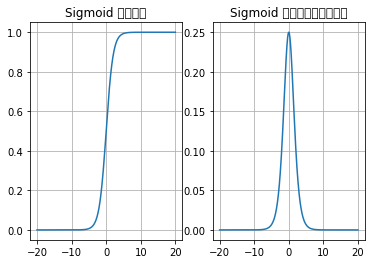

In [5]:
import torch
import matplotlib.pyplot as plt

# 创建画布和坐标轴
_, axes = plt.subplots(1, 2)
# 函数图像
x = torch.linspace(-20, 20, 1000)
y = torch.sigmoid(x)
axes[0].plot(x, y)
axes[0].grid()
axes[0].set_title("Sigmoid 函数图像")

y_deriv = y * (1 - y)
axes[1].plot(x, y_deriv)
axes[1].grid()
axes[1].set_title("Sigmoid 激活函数的导数图像")

#### Tanh 激活函数
Tanh公式：$ f(x) = \frac{1-e^{-2x}}{1+e^{-2x}} $
激活函数求导公式：$ f'(x) = (\frac{1-e^{-2x}}{1+e^{-2x}})' = 1 - f^2(x) $